<a href="https://colab.research.google.com/github/algroznykh/notebooks/blob/master/fourier_conj_wrap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

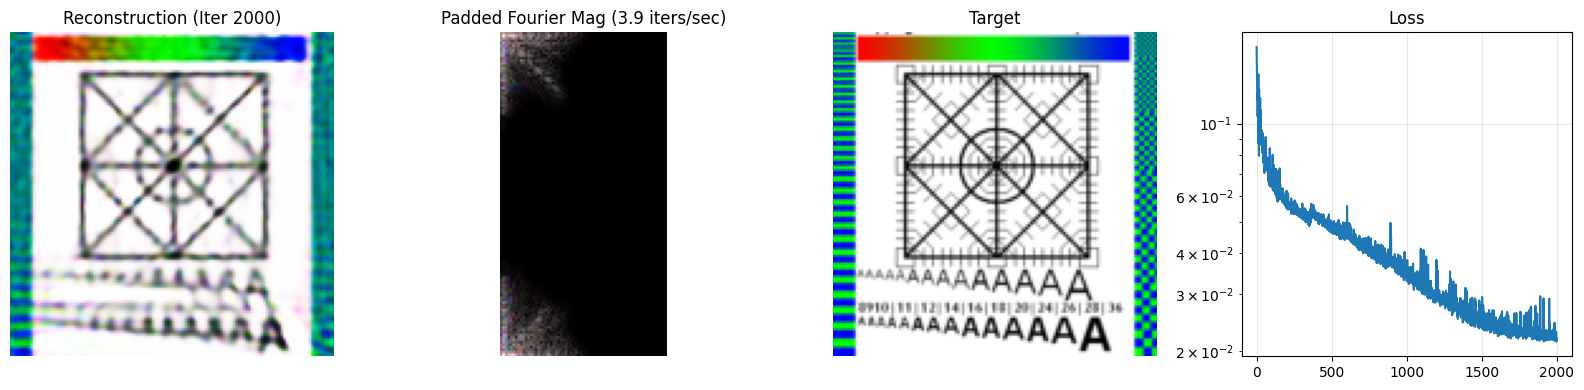

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import time
import random
import requests
from PIL import Image
import io
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

# =========================================================
# 1. CONFIGURATION
# =========================================================
CFG = {
    "size": 128,
    "ch": 32,
    "steps_min": 64,
    "steps_max": 96,
    "lr": 3e-3,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "target_url": "https://i.imgur.com/X2UkgS7.png",
    "pool_size": 128,
    "batch_size": 4
}

# =========================================================
# 2. FAST NATIVE COMPLEX HERMITIAN PADDING & ENFORCEMENT
# =========================================================
def fast_periodic_conjugate_reflection(col, flip_idx):
    # Circular height-flip along dim=2 using precomputed indices, then conjugate natively
    return torch.conj(col[:, :, flip_idx])

def hermitian_pad(z, flip_idx, pad_idx_h, pad=1):
    # Left padding (DC boundary, v=-1): periodic conjugate reflection of column 1
    col_left = fast_periodic_conjugate_reflection(z[:, :, :, 1:1+pad], flip_idx)
    # Right padding (Nyquist boundary, v=W_fft): periodic conjugate reflection of column W_fft-2
    col_right = fast_periodic_conjugate_reflection(z[:, :, :, -1-pad:-1], flip_idx)

    if pad > 1:
        col_left = col_left.flip(dims=[3])
        col_right = col_right.flip(dims=[3])

    z_wpad = torch.cat([col_left, z, col_right], dim=3)

    # Circular padding along the periodic vertical height dimension (dim=2)
    return z_wpad[:, :, pad_idx_h]

def enforce_hermitian(z, flip_idx):
    """
    Natively projects DC (v=0) and Nyquist (v=-1) columns onto the
    Hermitian-symmetric manifold using precomputed conjugate indices.
    """
    z_sym = z.clone()
    z_sym[:, :, :, 0] = 0.5 * (z[:, :, :, 0] + torch.conj(z[:, :, flip_idx, 0]))
    z_sym[:, :, :, -1] = 0.5 * (z[:, :, :, -1] + torch.conj(z[:, :, flip_idx, -1]))
    return z_sym

# =========================================================
# 3. SELF-ORGANIZING COMPLEX CA MODEL (100% LOCAL)
# =========================================================
class FourierCA(nn.Module):
    def __init__(self, ch, limit=400.0):
        super().__init__()
        self.ch = ch
        self.limit = limit
        # Standard convolutions process real and imaginary parts concatenated
        self.conv1 = nn.Conv2d(ch * 2, ch * 4, 3, padding=0, bias=False)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(ch * 4, ch * 2, 1, bias=False)

    def forward(self, z, flip_idx, pad_idx_h):
        # 1. Native Hermitian pad using precomputed GPU indices (extremely fast)
        z_pad = hermitian_pad(z, flip_idx, pad_idx_h, pad=1)

        # 2. Concatenate real/imag components for Conv1
        z_ri = torch.cat([z_pad.real, z_pad.imag], dim=1)

        h = self.relu(self.conv1(z_ri))
        dz_ri = self.conv2(h)

        # 3. Reconstruct complex delta
        dz = torch.complex(dz_ri[:, :self.ch], dz_ri[:, self.ch:])

        # 4. Local additive update
        z_new = z + 0.1 * dz

        # 5. Enforce Hermitian symmetry on DC and Nyquist natively
        z_new = enforce_hermitian(z_new, flip_idx)

        # 6. Magnitude squashing (phase-preserving)
        mag = torch.abs(z_new)
        scale = self.limit * torch.tanh(mag / self.limit) / (mag + 1e-8)
        return z_new * scale

# =========================================================
# 4. TARGET IMAGE ACQUISITION
# =========================================================
def get_target(url, size, device):
    try:
        headers = {'User-Agent': 'Mozilla/5.0'}
        response = requests.get(url, headers=headers, timeout=10)
        img = Image.open(io.BytesIO(response.content)).convert('RGB')
        img = img.resize((size, size), Image.Resampling.BILINEAR)
        target = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
        print("Successfully fetched target image.")
    except Exception as e:
        print(f"Could not load image from URL ({e}). Falling back to procedural target.")
        y, x = torch.meshgrid(
            torch.linspace(-1, 1, size, device=device),
            torch.linspace(-1, 1, size, device=device),
            indexing='ij'
        )
        target = torch.zeros(3, size, size, device=device)
        target[0] = (torch.sin(10 * x) * torch.cos(10 * y) > 0.0).float()
        target[1] = (torch.sin(20 * x) > 0.0).float()
        target[2] = (torch.cos(20 * y) > 0.0).float()

    if target.ndim == 3:
        target = target.unsqueeze(0)
    return target.to(device)

# =========================================================
# 5. VISUALIZATION UTILITY
# =========================================================
def plot_progress(losses_history, rec_img, tgt_img, z_pad_coeff, step, fps):
    mag = torch.abs(z_pad_coeff[:3]).detach().cpu()
    mag_log = torch.log1p(mag)
    t_mag = (mag_log - mag_log.min()) / (mag_log.max() - mag_log.min() + 1e-8)
    mag_img = (t_mag.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    clear_output(wait=True)
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(rec_img)
    axes[0].set_title(f"Reconstruction (Iter {step})")
    axes[0].axis('off')

    axes[1].imshow(mag_img)
    axes[1].set_title(f"Padded Fourier Mag ({fps:.1f} iters/sec)")
    axes[1].axis('off')

    axes[2].imshow(tgt_img)
    axes[2].set_title("Target")
    axes[2].axis('off')

    axes[3].plot(losses_history, color='#1f77b4')
    axes[3].set_title("Loss")
    axes[3].set_yscale('log')
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# =========================================================
# 6. TRAINING ENGINE
# =========================================================
def train(iterations=2000, viz_every=100):
    device = CFG["device"]
    H, W = CFG["size"], CFG["size"]
    W_fft = W // 2 + 1
    ch = CFG["ch"]

    model = FourierCA(ch).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=CFG["lr"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=iterations, eta_min=1e-5)
    target = get_target(CFG["target_url"], CFG["size"], device)

    # 1. Precompute height flip indices (DC row stays, others reverse)
    flip_idx = torch.cat([torch.tensor([0], device=device), torch.arange(H - 1, 0, -1, device=device)])

    # 2. Precompute circular pad indices along the height axis (dim=2)
    pad_idx_h = torch.cat([torch.tensor([H - 1], device=device), torch.arange(H, device=device), torch.tensor([0], device=device)])

    # Initialize State Pool as native complex64 tensors
    pool = torch.zeros(CFG["pool_size"], ch, H, W_fft, dtype=torch.complex64, device=device)
    pool[:, :, 0, 0] = 1.0

    losses_gpu = []
    t0 = time.time()

    for i in range(1, iterations + 1):
        idx = torch.randperm(CFG["pool_size"], device=device)[:CFG["batch_size"]]

        z = pool[idx].clone()
        z[0] = 0.0
        z[0, :, 0, 0] = 1.0

        num_steps = random.randint(CFG["steps_min"], CFG["steps_max"])

        # Executes at native GPU speeds with no complex-layout penalties
        for _ in range(num_steps):
            z = model(z, flip_idx, pad_idx_h)

        spatial = torch.fft.irfft2(z, s=(H, W), norm='ortho')
        rgb = torch.sigmoid(spatial[:, :3])
        loss = F.mse_loss(rgb, target.expand(CFG["batch_size"], -1, -1, -1))

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        scheduler.step()

        pool[idx] = z.detach()
        losses_gpu.append(loss.detach())

        if i % viz_every == 0 or i == iterations:
            fps = viz_every / (time.time() - t0)
            t0 = time.time()

            losses_cpu = torch.stack(losses_gpu).cpu().numpy()

            rec_img = (rgb[0].detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            tgt_img = (target[0].cpu().clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype(np.uint8)

            # Pass the actual padded complex spectrum directly to the progress plotter
            z_pad = hermitian_pad(z, flip_idx, pad_idx_h, pad=1)
            plot_progress(losses_cpu, rec_img, tgt_img, z_pad[0], i, fps)

    return model

# Execute the training sequence and return the model
model = train(iterations=2000, viz_every=100)